In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Loading in the dataset
df = pd.read_csv("shopify_sales_dataset_ml_eda.csv")

In [9]:
# Bringing in the first five rows or the head
df.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [10]:
# The shape or records (rows) and columns
df.shape

(60000, 17)

In [11]:
# Data type and also which rows might need to be changed to an intger like shipping method and type of payment method is an object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

In [12]:
# Here i'm just serching for missing values in the dataset and it looks good so far
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values per column:
order_id            0
order_date          0
customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
traffic_source      0
payment_method      0
shipping_cost       0
rating              0
is_returned         0
discounted_price    0
revenue             0
profit              0
dtype: int64

Duplicate rows:
0


In [13]:
# Next i'll convert the order_date as a proper date rather than text.
df['order_data'] = pd.to_datetime(
    df['order_date'],
    errors='coerce'
)

print("Data type:", df['order_date'].dtype)
print("Invalid dates:", df['order_date'].isna().sum())
print("Earliest order:", df['order_date'].max())

Data type: object
Invalid dates: 0
Earliest order: 2025-06-18


In [14]:
# Here i'll check the identifiers to understand whether each row reprsents a unique order or an item with an order
print("Total rows:", len(df))
print("Unique order IDs:", df['order_id'].nunique())
print("Unique customers:", df['customer_id'].nunique())
print("Unique product:", df['product_id'].nunique())

Total rows: 60000
Unique order IDs: 60000
Unique customers: 31154
Unique product: 6998


In [15]:
# I'll examin the numerical values thois will give me a minimum and maximum average for each numerical value


In [16]:
df[
    ['product_price',
     'discount_percent',
     'quantity',
     'shipping_cost',
     'rating',
     'discounted_price',
     'revenue',
     'profit'
    ]
].describe().T
     

,count,mean,std,min,25%,50%,75%,max
product_price,60000.0,403.427068,230.045257,5.01,203.1600,403.855,603.1350,799.99
discount_percent,60000.0,18.151500,12.527663,0.00,5.0000,20.000,30.0000,40.00
quantity,60000.0,3.009567,1.414794,1.00,2.0000,3.000,4.0000,5.00
shipping_cost,60000.0,13.521758,6.627934,2.00,7.7600,13.580,19.2300,25.00
rating,60000.0,3.002440,1.152265,1.00,2.0000,3.000,4.0000,5.00
discounted_price,60000.0,330.220212,197.114822,3.08,161.9575,322.560,482.2425,799.90
revenue,60000.0,994.098926,806.445785,3.08,355.6200,760.470,1462.4500,3999.50
profit,60000.0,980.577168,806.508355,-20.49,341.9250,747.275,1449.8075,3989.95


A useful observation
the average values are:
Product price $403.43
Discounted price  $330.22
Revenue $994.10
profit  $980.58
And the average quantity is about 3 units per order
* Here are the relationships we can invstigate
* Does a largeer dicount increase quanitity?
* Does discounting increase revenue?
* Does discountin reduce profit?
* Which product categories generate the most revenue?
* Which countries generate the most sales?
* Which traffic source produce the most revenue?
* Are-Higher rated products associated with higher revenue?
* Are returned orders associated with lower rarings?
* Which customers purchase the most frequently

In [17]:
# One more thing before visualization, I want to verify the business calculations
# Calculte the dicouted price and validate the data
df['expected_discounted_price'] = (
    df['product_price'] * ( - df['discount_percent'] /100)
)

# Compare expected vs. actual
df['price_difference'] = (
    df['discounted_price'] - df['expected_discounted_price']
)
df['price_difference'].describe()
    

count    60000.000000
mean       403.427040
std        230.045262
min          5.010000
25%        203.164000
50%        403.853500
75%        603.137500
max        799.988500
Name: price_difference, dtype: float64

In [18]:
# Calculate expected revenue
df['expected_revenue'] = (
    df['discounted_price'] * df['quantity']
)

# Compare expected vs actual
df['revenue_difference'] = (
    df['revenue'] - df['expected_revenue']
)
df['revenue_difference'].describe()

count    6.000000e+04
mean     4.220032e-16
std      8.230828e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: revenue_difference, dtype: float64

In [19]:
# Check the relationship between revenue, shipping cost, and profit
df['profit_difference'] = (
    df['profit'] - (df['revenue'] - df['shipping_cost'])
)
df['profit_difference'].describe()

count    6.000000e+04
mean     5.936258e-16
std      1.032475e-13
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: profit_difference, dtype: float64

In [20]:
df[
    [
        'product_price',
        'discount_percent',
        'discounted_price'
    ]
    ].head(10)

,product_price,discount_percent,discounted_price
0,143.39,40,86.03
1,746.49,15,634.52
2,641.06,5,609.01
3,512.39,0,512.39
4,415.89,25,311.92
5,444.14,0,444.14
6,244.18,15,207.55
7,457.16,25,342.87
8,394.28,15,335.14
9,363.69,30,254.58


Now I can start the EDA, but first I want to check the orde_date is actually a datetime column

In [21]:
print(df['order_date'].dtype)

object


In [22]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [23]:
print(df['order_date'].dtype)

datetime64[ns]


In [24]:
# Here I'll create a dataframe for the total monthly revenue
monthly_revenue = (
    df.groupby(df['order_date'].dt.to_period('M'))['revenue']
        .sum()
        .reset_index()
        )
monthly_revenue['order_date'] = monthly_revenue['order_date'].astype(str)
monthly_revenue.head()

,order_date,revenue
0,2023-01,2102673.23
1,2023-02,1872331.83
2,2023-03,2132980.04
3,2023-04,2028363.58
4,2023-05,2045229.81


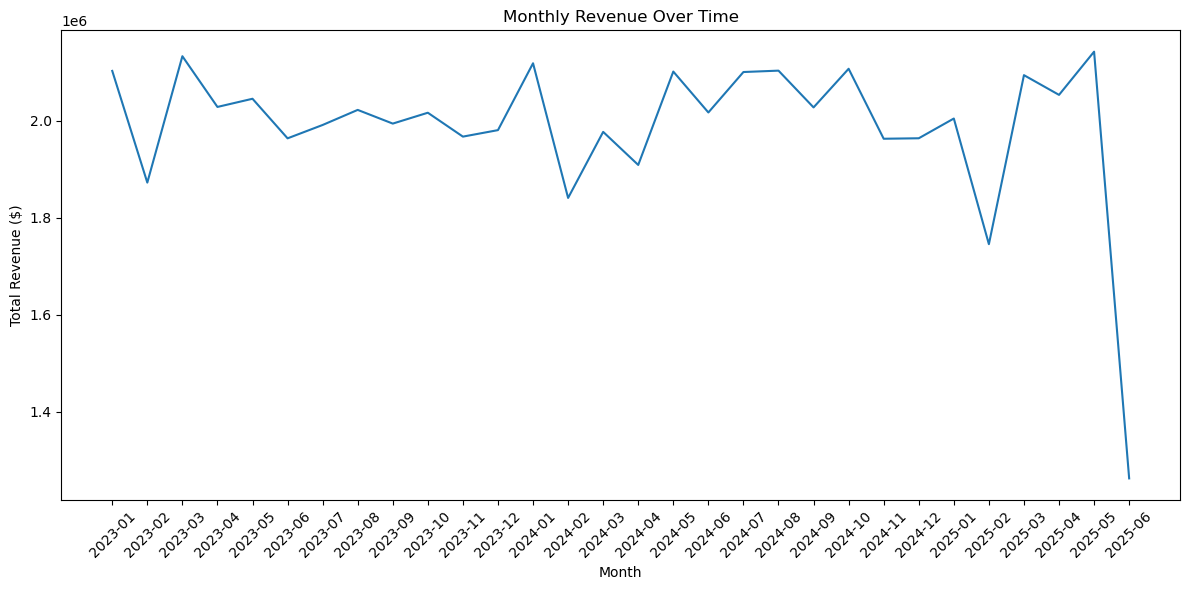

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['order_date'],
    monthly_revenue['revenue']
)

plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
    

In [26]:
df['order_date'].dt.to_period('M')

0        2023-04
1        2024-03
2        2025-05
3        2023-09
4        2023-04
          ...   
59995    2025-04
59996    2024-09
59997    2024-11
59998    2023-09
59999    2025-06
Name: order_date, Length: 60000, dtype: period[M]

In [27]:
monthly_revenue.head(10)

,order_date,revenue
0,2023-01,2102673.23
1,2023-02,1872331.83
2,2023-03,2132980.04
3,2023-04,2028363.58
4,2023-05,2045229.81
5,2023-06,1963611.53
6,2023-07,1991172.73
7,2023-08,2022262.33
8,2023-09,1994009.64
9,2023-10,2016415.95


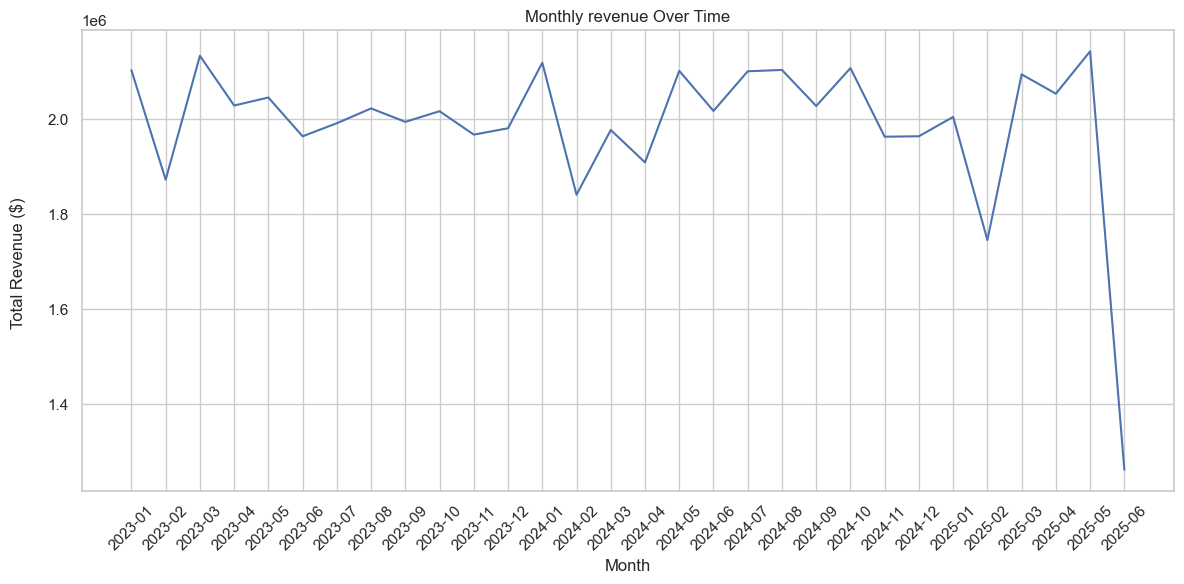

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['order_date'],
    monthly_revenue['revenue']
)

plt.title('Monthly revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($) ', labelpad=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
          

In [29]:
plt.savefig('monthly_revenue.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Revenue trend finding: Monthly revenue remained reletavely stable throughout the observed period, generally ranging between approximately $1.75ML  and  $2.15ML. Although there are several mont-to-month fluctuations and notable dips, revenue generally returns to its previous range, suggesting relatively consistent sales over time.
Next I'll get the highet and lowest months.

In [30]:
highest_month = monthly_revenue.loc[
    monthly_revenue['revenue'].idxmax()
    ]
lowest_month = monthly_revenue.loc[
    monthly_revenue['revenue'].idxmin()
    ]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
order_date       2025-05
revenue       2142348.02
Name: 28, dtype: object

Lowest Revenue Month:
order_date       2025-06
revenue       1262287.97
Name: 29, dtype: object


Highest revenue:  May 2025: $2,142,348.02
Lowest Revenue: June 2025: $1,262,287.97
That's a substatial change between two consecutive months. Revenue decreased about 41.1%
from May to June 2025. I'll investigate the June drop to determine whether June had 
1. Fewer orders
2. Lower quantities per prder
3. Lower average order value
4. Some combunation of these

In [31]:
monthly_orders = (
    df.groupby(df['order_date'].dt.to_period('M'))
    .agg(
        orders=('order_id', 'count'),
        revenue=('revenue', sum)
    )
    .reset_index()
)

monthly_orders.head()

C:\Users\User\AppData\Local\Temp\ipykernel_16084\3126350827.py:3: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg(


,order_date,orders,revenue
0,2023-01,2106,2102673.23
1,2023-02,1847,1872331.83
2,2023-03,2096,2132980.04
3,2023-04,2026,2028363.58
4,2023-05,2013,2045229.81


In [32]:
monthly_orders[
    monthly_orders['order_date'].isin([
        pd.Period('2025-05', freq='M'),
        pd.Period('2025-06', freq='M')
    ])
    ]

,order_date,orders,revenue
28,2025-05,2090,2142348.02
29,2025-06,1232,1262287.97


In [33]:
monthly_orders['average_order_value'] = (
    monthly_orders['revenue'] / monthly_orders['orders']
)

monthly_orders[
    monthly_orders['order_date'].isin([
        pd.Period('2025-05', freq='M'),
        pd.Period('2025-06', freq='M')
    ])
    ]

,order_date,orders,revenue,average_order_value
28,2025-05,2090,2142348.02,1025.046900
29,2025-06,1232,1262287.97,1024.584391


Revenue Trend Finding: Monthly revenue remained relatively stable across most of the study
period. May 2025 recorded the highest monthly revenue at 2.14 million, while june 2025 recoreded
the lowest at 1.26 million. the decline was primarily associated with a 41% decrease in order volume
from 2,090 orders in May to 1,232 in June. average order value remained nearly unchanged
at approximately $1025, indicating that the revenue decline was driven by primarily by fewer orders
rather than lower revenue per order.

In [34]:
category_revenue = (
    df.groupby('product_category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)

category_revenue

,product_category,revenue
0,Electronics,8717301.49
1,Accessories,8609171.52
2,Home Decor,8545840.45
3,Beauty,8544881.95
4,Fashion,8445072.67
5,Sports,8434698.81
6,Footwear,8348968.69


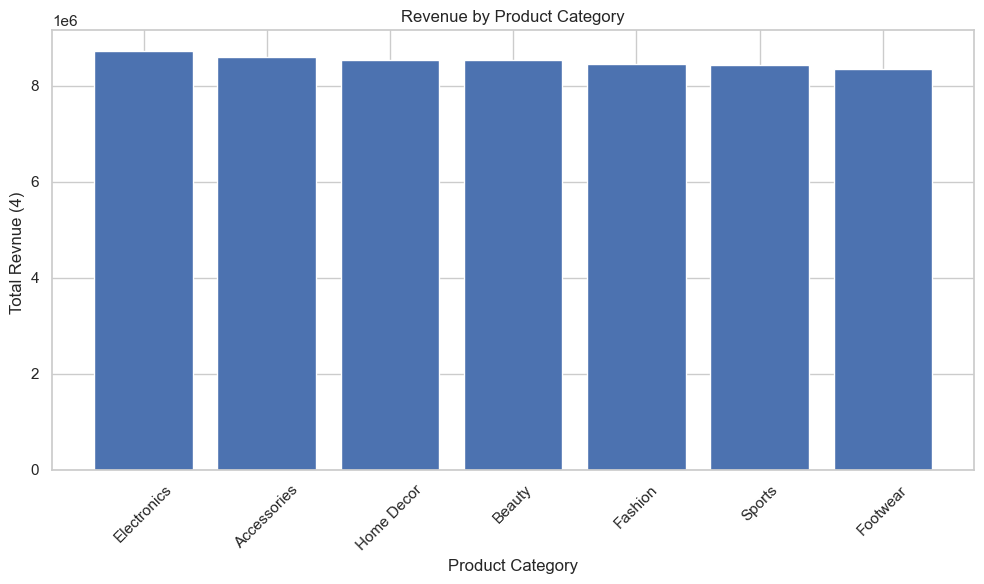

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue['product_category'],
    category_revenue['revenue']
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revnue (4) ')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
country_revenue = (
    df.groupby('customer_country')['revenue']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

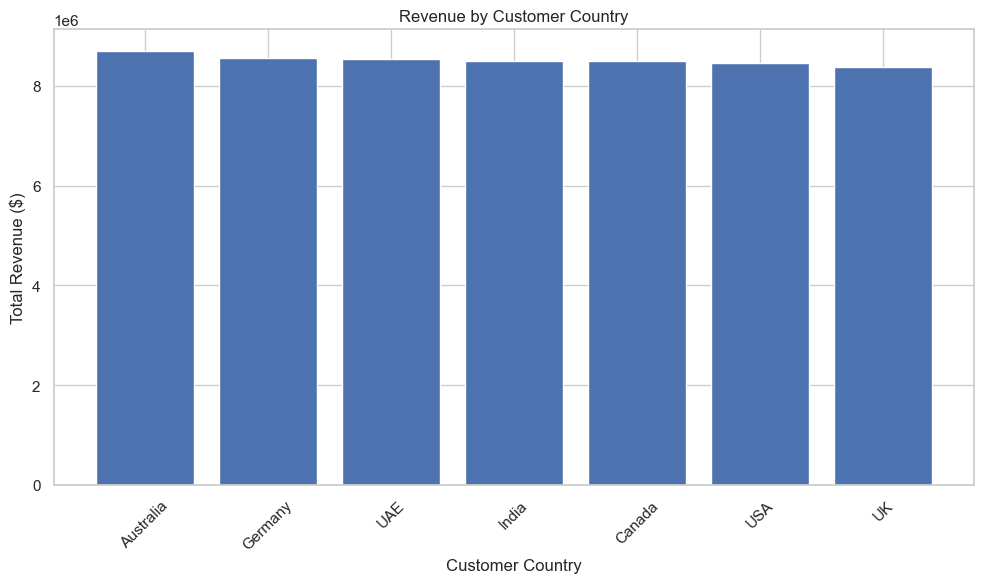

In [37]:
plt.figure(figsize=(10, 6))

plt.bar(
    country_revenue['customer_country'],
    country_revenue['revenue']
)

plt.title('Revenue by Customer Country')
plt.xlabel('Customer Country')
plt.ylabel('Total Revenue ($)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

        
    

Revenue By Country: 
* Australia appears to hace the highest revenue.
* UK appears to have the lowest
* Germany, UAE, India, Canada and the USA fall between them.
* The differences are relatively small compared with overall revenue generated by each country
This is similar to what we found found with product categories: There isn't one countr dominating the business.

In [38]:
country_revenue

,customer_country,revenue
0,Australia,8698940.71
1,Germany,8566995.25
2,UAE,8541233.92
3,India,8509138.00
4,Canada,8506629.46
5,USA,8450978.82
6,UK,8372019.42


What does this tell us?
Again, the revenue is very balanced.
* Australia has the highest revenue: $8.70 million
* The UK has the lowest: $8.37 million
* The difference is only about $326,921
* No single country accounts for a dramatically larger dhare of revenue than the others
Patterns or trends: Product categories = balanced revenue
                    Countries          = balanced revenue
                    Monthly revenue    = generally stable

Now I can investigate where the customers are coming from each five sources
* Organic
* Paid
* Social
* Referal
* Direct

In [39]:
traffic_orders = (
    df['traffic_source']
    .value_counts()
    .reset_index()
)

traffic_orders.columns = ['traffic_source', 'orders']

traffic_orders

,traffic_source,orders
0,Organic,12075
1,Social Media,12024
2,Paid Ads,12018
3,Direct,11961
4,Email,11922


In [41]:
traffic_revenue = (
    df.groupby('traffic_source')['revenue']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

traffic_revenue   

,traffic_source,revenue
0,Social Media,12021807.48
1,Direct,11953141.33
2,Paid Ads,11939378.20
3,Organic,11907664.90
4,Email,11823943.67


What stands out? 
Social Media generated most revenue about $12.02 million.
Email generated the least about $11.80 million.
The difference between the highest and lowest source is only: $197,863.81
That's a relatively small difference considering each source generateed roughly $12 million.
No single traffic source diminates revenue.

Traffic source finding: Revenue was relatively evenly distributed across all
five traffic sources. Social Media generated the highest revenue at
approximately $12.02 million, while email generated the lowest at approximately
$11.82 million. the relatively small difference of approximately $198,00 indicates that no single traffic source substantially domiantes revenue generation.

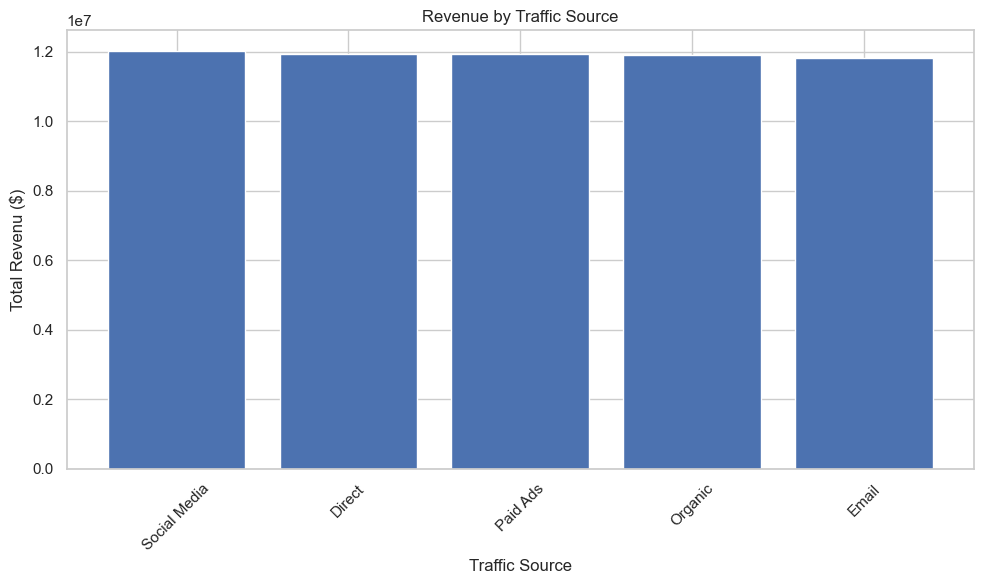

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    traffic_revenue['traffic_source'],
    traffic_revenue['revenue']
)

plt.title('Revenue by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Total Revenu ($)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

           

In [47]:
discount_analysis = (
    df.groupby('discount_percent')
    .agg(
        orders=('order_id', 'count'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum')
    )
    .reset_index()
)

discount_analysis

,discount_percent,orders,revenue,profit
0,0,7567,9094742.14,8992483.76
1,5,7460,8688791.19,8588094.59
2,10,7524,8191231.64,8089483.38
3,15,7406,7715510.16,7614885.42
4,20,7446,7247897.32,7145981.96
5,25,7466,6763485.72,6662983.36
6,30,7535,6464980.80,6363535.61
7,40,7596,5479296.61,5377182.02


Are higher discounts producing less revenue and profit per order?

In [50]:
discount_analysis['revenue_per_order'] = (
    discount_analysis['revenue'] / discount_analysis['orders']
)

discount_analysis['profit_per_order'] = (
    discount_analysis['profit'] / discount_analysis['orders']
)

discount_analysis


,discount_percent,orders,revenue,profit,revenu_per_order,profit_per_order,revenue_per_order
0,0,7567,9094742.14,8992483.76,1201.895354,1188.381625,1201.895354
1,5,7460,8688791.19,8588094.59,1164.717318,1151.219114,1164.717318
2,10,7524,8191231.64,8089483.38,1088.680441,1075.157281,1088.680441
3,15,7406,7715510.16,7614885.42,1041.791812,1028.204891,1041.791812
4,20,7446,7247897.32,7145981.96,973.394752,959.707489,973.394752
5,25,7466,6763485.72,6662983.36,905.904865,892.443525,905.904865
6,30,7535,6464980.80,6363535.61,857.993470,844.530273,857.993470
7,40,7596,5479296.61,5377182.02,721.339733,707.896527,721.339733


In [51]:
rating_counts = df['rating'].value_counts().sort_index()
rating_counts

rating
1.0     738
1.1    1457
1.2    1516
1.3    1431
1.4    1477
1.5    1492
1.6    1508
1.7    1533
1.8    1511
1.9    1468
2.0    1516
2.1    1512
2.2    1455
2.3    1484
2.4    1523
2.5    1517
2.6    1492
2.7    1536
2.8    1530
2.9    1553
3.0    1491
3.1    1556
3.2    1497
3.3    1481
3.4    1515
3.5    1519
3.6    1475
3.7    1525
3.8    1470
3.9    1479
4.0    1467
4.1    1555
4.2    1511
4.3    1498
4.4    1467
4.5    1529
4.6    1474
4.7    1478
4.8    1504
4.9    1517
5.0     743
Name: count, dtype: int64

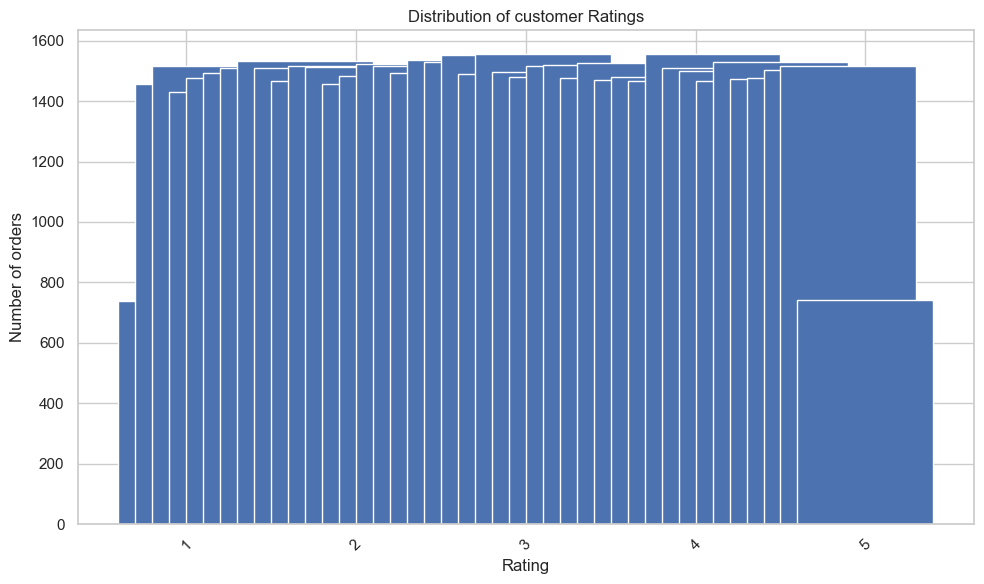

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(rating_counts.index, rating_counts.values)

plt.title('Distribution of customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of orders')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Here we can see the rating distribution plotted out         

In [55]:
rating_analysis = (
    df.groupby('rating')
    .agg(
        orders=('order_id', 'count'),
        revenue=('revenue', 'sum'),
        profit=('profit', 'sum')
    )
    .reset_index()
)

rating_analysis['revenue_per_order'] = (
    rating_analysis['revenue'] / rating_analysis['orders']
)

rating_analysis['profit_per_order'] = (
    rating_analysis['profit'] / rating_analysis['orders']
)
    
rating_analysis.head(10)            

,rating,orders,revenue,profit,revenue_per_order,profit_per_order
0,1.0,738,738671.82,728688.88,1000.910325,987.383306
1,1.1,1457,1465327.15,1445699.37,1005.715271,992.243905
2,1.2,1516,1510449.78,1489742.80,996.338905,982.679947
3,1.3,1431,1397026.11,1377764.75,976.258637,962.798567
4,1.4,1477,1478979.36,1458881.63,1001.340122,987.732993
5,1.5,1492,1545093.63,1524678.99,1035.585543,1021.902808
6,1.6,1508,1457051.91,1436720.32,966.214794,952.732308
7,1.7,1533,1501703.24,1480994.65,979.584631,966.076093
8,1.8,1511,1534789.22,1514504.60,1015.744024,1002.319391
9,1.9,1468,1471815.94,1452395.62,1002.599414,989.370313


So we cannot claim that higher ratings produce higher revenue. The data
doesn't show an obvious relationship from the results.
Next I'll calculate the overall relationship between rating and the financial varables.

In [56]:
rating_analysis[['rating', 'revenue_per_order', 'profit_per_order']].corr()

,rating,revenue_per_order,profit_per_order
rating,1.000000,0.004910,0.005284
revenue_per_order,0.004910,1.000000,0.999972
profit_per_order,0.005284,0.999972,1.000000


This gives us the correlation between:
* Rating
* Revenue per order
* Profit per order

In [57]:
rating_analysis.sort_values(
    'revenue_per_order',
    ascending=False).head(5)

,rating,orders,revenue,profit,revenue_per_order,profit_per_order
38,4.8,1504,1561109.00,1540434.99,1037.971410,1024.225392
28,3.8,1470,1522595.96,1502781.26,1035.779565,1022.300177
5,1.5,1492,1545093.63,1524678.99,1035.585543,1021.902808
13,2.3,1484,1523825.96,1503934.09,1026.836900,1013.432675
30,4.0,1467,1502822.88,1483538.28,1024.419141,1011.273538


In [59]:
rating_analysis.sort_values(
    'revenue_per_order',
    ascending=True).head(5)

,rating,orders,revenue,profit,revenue_per_order,profit_per_order
37,4.7,1478,1403628.74,1384079.29,949.681150,936.454188
12,2.2,1455,1386073.22,1366659.47,952.627643,939.284859
20,3.0,1491,1422748.92,1402184.71,954.224628,940.432401
24,3.4,1515,1456662.26,1435817.55,961.493241,947.734356
15,2.5,1517,1459211.26,1438193.89,961.905906,948.051345


Customer rartings showed virtually no linear relationship with fifnacial performance

In [60]:
print("Earliest date:", df['order_date'].min())
print("latest_date:", df['order_date'].max())

Earliest date: 2023-01-01 00:00:00
latest_date: 2025-06-18 00:00:00


My professional interpretaition is:
May 2025 recorded the highest complete month revenu at approximately $ 2.14 million
June 2025 recorded $1.26 million through june 18th; because June is an incomplte month its 
revenue shhould not be directly compared with full months

"What factors are associated with product returns?"

In [61]:
return_counts = df['is_returned'].value_counts()

return_counts

is_returned
0    51113
1     8887
Name: count, dtype: int64

In [63]:
return_rate = df['is_returned'].mean() * 100

print(f"Overall return rate: {return_rate:.2f}%")

Overall return rate: 14.81%


In [68]:
return_by_category = (
    df.groupby('product_category')
    .agg(
        orders=('order_id', 'count'),
        returned_orders=('is_returned', 'sum')
    )
    .reset_index()
)

return_by_category['return_rate'] = (
    return_by_category['returned_orders'] /
    return_by_category['orders'] * 100
)

return_by_category.sort_values(
    'return_rate',
    ascending=False
)


,product_category,orders,returned_orders,return_rate
6,Sports,8522,1297,15.219432
3,Fashion,8594,1292,15.033744
1,Beauty,8586,1289,15.012812
4,Footwear,8457,1245,14.721532
0,Accessories,8617,1262,14.645468
2,Electronics,8624,1262,14.633581
5,Home Decor,8600,1240,14.418605


Reurns analysis: The overall return rate was 14.81%. Sports had the highest return
rate at 15.22%, while home decor had the lowest at 14.22%. The relatively small differnce of 0.80 percentage points indicates that return behavior was braodly
consistent accross product categories, with no category dramatically higher return rate than others.

SHOPIFY SALES DATASET - EDA REPORT
1. Project orverview
Project: Shopify Sales dataset for Machinelearning & EDA
Analysis Tool: Python/ Jupyter Notebook
Primary libraries: Pandas, Numpy, Matplotlib
Dataset Size 60,000 orders x 17 variables

Objective
The purpose of this projesct was to perrform an EDA analysis of Shopify sales data
to identify patterns in:
* Sales and revenue trends
* Produc-category performance
* Geographic performance
* Marketing and traffic sources
* Discounting
* Customer Ratings
* product returns
* Revenue and profit performnance
2. Data Cleaning and Validation
  The initial inspection found
* 60,000 rows
* 17 columns
* 0 missing values
* 0 duplicate rows

# the order_data column was converted from an object using
df[order_date =pd.to_datetime(....

# The dataset contain:
* 60,000 unique orders
* 31,154 unique customers
* 6998 unique products
Because every order_id is unique, each row can initially be treated as an individual order for order-level analysis

# Financial Data Calidation
Several calculations were independently validated.
1. Discounted_price * (1 - discount_percent / 100)
The calculated values were consistent
2. Revenue - discounted_ price * quantity
The difference between calculated and recorded revenue was effectively zero, with only tiny floating differences
3. Profit - revenu - shipping_cost
Again, the difference was effectively zero.
# Finding
The dataset's core pricing revenue,a nd profit calculations were internally consistent.
This increases confidence that the financial fields can beused for subsequent analysis.
# Revenue Analysis
Revenue over time:
the highest complete month was:
May 2025 - $2,142,348.02
the dataset ends on June 18, 2025
# Finding
Momnthly revenue remained stable accross the avaiable complete months, with May 2025 generating appoximately $2.14 million. June 2025 was excuded from full-month comparisons because the dataset ends on June 18th, making it a partial momnth.
This is an importan data-quality consideration because comparing an imcomplete month with full months could produce a misleading conclusion about sales performance.
# Revenue by Product Category
,Revenue was e,venly distributed acoss the seven product categories
Electronics $8,717,301.49
Accessories $8,609,840.45
Home Decor  $8,544,881.95
Beauty      $8,544,881.95
Fashion     $8,445,072.67
Sports      $8,434,698.81
Footweat    $8,348,968.69
# Findings
Electronics generated the highets revenu at apptoiximately $8.72 million, while footwera generated the lowes at approximately $8.35 million. The relatively small difference between the highest and lowes performing categories indicates that revenue was broadly distributed rather than dominated by one category
# Revenue by Customer Country
Australia $,8,,698,940.71
Germany   $8,566,995.25
UAE       $8,541,233.92
India     $8,509,138.00
Canada    $8,506,629.46
USA       $8,450,978.82
UK        $8,372,019.42
# Finding
Australia generated the highest revenue at approximately $8.70 million, while the UK GENERATED THE LOWEST AT $8.37. The relatively small difference was broadly distributed across the international customer base.
# Traffic Source Analysis
Oder balanc was highly balanced accross traffic sources
Organic  12,075
Social Media 12,024
Paid Ads 12,018
Direct 11,961
Email 11,922
# Revenue by traffic Source
Social Media  $12,021,807.48
Direct $11,953,141.33
Paid Ads $11,939,378
Organis $11,907,664.90
Email $11,823,943.67
# Finding
Social Media generated the highest revenue at $12.02 million, while Email generated $11.82 million. the relatively small difference between traffic sources suggest that no single channel overwhelmingly dominates 
# Key Findings
* Revenue was broadly distributed, Electronics generated the most revenue
* Australia had the highest revenue
* Social Media generated the highest traffic-source revenue.
* Higher discoun levels were associate woth lower revenue and profit per order
* customer ratings had no linear relationship with profit
* The overall return rate was 14.81%, with relatively little variation between categories
  # Recommendations
1. Evaluate dicount strategy - Higher discount were associated with lower revenue
2. Investigate customer returns - at 14.81% warrants additional investigation
# Conclusion
This sxploratoty analysis examined 60,000 shopify orders accross sales, products, customers, geography, marketing channels, and returns
The analysis found that the revenu was evenly distributed accross product categories, countries, and traffic sources. Electronics was was the highest-revenue category, Australia was the highest-revenu country, and Social Media was the highest-revenue traffic source.
The strongest finacial pattern identifed was the association between discount levels and revenueprofit per order. Higher discounts correspond with lower revenue and profit per order.